In [1]:
import pandas as pd

calendar = pd.read_csv("AdventureWorks Calendar Lookup.csv")

In [2]:
import matplotlib.pyplot as plt
import seaborn as seb

In [3]:
p_category = pd.read_csv("AdventureWorks Product Categories Lookup.csv")
product = pd.read_csv("AdventureWorks Product Lookup.csv")
p_subcategories = pd.read_csv("AdventureWorks Product Subcategories Lookup.csv")

territory = pd.read_csv("AdventureWorks Territory Lookup.csv")
returns = pd.read_csv("AdventureWorks Returns Data.csv")

sales_2020 = pd.read_csv("AdventureWorks Sales Data 2020.csv")
sales_2021 = pd.read_csv("AdventureWorks Sales Data 2021.csv")
sales_2022 = pd.read_csv("AdventureWorks Sales Data 2022.csv")

In [4]:
customers = pd.read_csv(
    r"AdventureWorks Customer Lookup.csv",
    encoding="latin1"
)

In [5]:
sales = pd.concat([sales_2020, sales_2021, sales_2022], ignore_index = True)

In [6]:
sales.shape
sales.head()

,OrderDate,StockDate,OrderNumber,ProductKey,CustomerKey,TerritoryKey,OrderLineItem,OrderQuantity
0,2020-01-01,2019-09-21,SO45080,332,14657,1,1,1
1,2020-01-01,2019-12-05,SO45079,312,29255,4,1,1
2,2020-01-01,2019-10-29,SO45082,350,11455,9,1,1
3,2020-01-01,2019-11-16,SO45081,338,26782,6,1,1
4,2020-01-02,2019-12-15,SO45083,312,14947,10,1,1


In [7]:
sales.columns
p_category.columns
calendar.columns
customers.columns
product.columns
p_subcategories.columns
territory.columns
returns.columns

Index(['ReturnDate', 'TerritoryKey', 'ProductKey', 'ReturnQuantity'], dtype='object')

In [8]:
product.columns
p_subcategories.columns
p_category.columns

Index(['ProductCategoryKey', 'CategoryName'], dtype='object')

In [9]:
full_production = pd.merge(product, p_subcategories, on="ProductSubcategoryKey", how="left")


In [10]:
full_production = pd.merge(full_production, p_category, on = "ProductCategoryKey", how = "left")

In [11]:
full_production.head()

,ProductKey,ProductSubcategoryKey,ProductSKU,ProductName,ModelName,ProductDescription,ProductColor,ProductSize,ProductStyle,ProductCost,ProductPrice,SubcategoryName,ProductCategoryKey,CategoryName
0,214,31,HL-U509-R,"Sport-100 Helmet, Red",Sport-100,"Universal fit, well-vented, lightweight , snap...",Red,0,0,13.0863,34.9900,Helmets,4,Accessories
1,215,31,HL-U509,"Sport-100 Helmet, Black",Sport-100,"Universal fit, well-vented, lightweight , snap...",Black,0,0,12.0278,33.6442,Helmets,4,Accessories
2,218,23,SO-B909-M,"Mountain Bike Socks, M",Mountain Bike Socks,Combination of natural and synthetic fibers st...,White,M,U,3.3963,9.5000,Socks,3,Clothing
3,219,23,SO-B909-L,"Mountain Bike Socks, L",Mountain Bike Socks,Combination of natural and synthetic fibers st...,White,L,U,3.3963,9.5000,Socks,3,Clothing
4,220,31,HL-U509-B,"Sport-100 Helmet, Blue",Sport-100,"Universal fit, well-vented, lightweight , snap...",Blue,0,0,12.0278,33.6442,Helmets,4,Accessories


In [12]:
full_production.isna().sum()

ProductKey                0
ProductSubcategoryKey     0
ProductSKU                0
ProductName               0
ModelName                 0
ProductDescription        0
ProductColor             50
ProductSize               0
ProductStyle              0
ProductCost               0
ProductPrice              0
SubcategoryName           0
ProductCategoryKey        0
CategoryName              0
dtype: int64

In [13]:
full_production['ProductColor'].fillna('NA', inplace=True)
full_production.isna().sum()

ProductKey               0
ProductSubcategoryKey    0
ProductSKU               0
ProductName              0
ModelName                0
ProductDescription       0
ProductColor             0
ProductSize              0
ProductStyle             0
ProductCost              0
ProductPrice             0
SubcategoryName          0
ProductCategoryKey       0
CategoryName             0
dtype: int64

In [14]:
sales.isna().sum()
sales.duplicated().sum()

np.int64(0)

In [15]:
sales.columns
full_production.columns
total_sales = pd.merge(sales, full_production, on = "ProductKey", how = "left")

total_sales.shape
total_sales.head()
total_sales.isna().sum()

OrderDate                0
StockDate                0
OrderNumber              0
ProductKey               0
CustomerKey              0
TerritoryKey             0
OrderLineItem            0
OrderQuantity            0
ProductSubcategoryKey    0
ProductSKU               0
ProductName              0
ModelName                0
ProductDescription       0
ProductColor             0
ProductSize              0
ProductStyle             0
ProductCost              0
ProductPrice             0
SubcategoryName          0
ProductCategoryKey       0
CategoryName             0
dtype: int64

In [16]:
total_sales.columns
customers.columns

customers.isna().sum()

CustomerKey         1
Prefix            133
FirstName           6
LastName            6
BirthDate           3
MaritalStatus       6
Gender            136
EmailAddress        6
AnnualIncome        6
TotalChildren       6
EducationLevel      6
Occupation          6
HomeOwner           6
dtype: int64

In [17]:
customers.dropna(subset=['CustomerKey'], inplace=True)

In [18]:
customers['Prefix'].fillna('Unknown', inplace=True)
customers['Gender'].fillna('Not Specified', inplace=True)
customers.isna().sum()

CustomerKey       0
Prefix            0
FirstName         5
LastName          5
BirthDate         2
MaritalStatus     5
Gender            0
EmailAddress      5
AnnualIncome      5
TotalChildren     5
EducationLevel    5
Occupation        5
HomeOwner         5
dtype: int64

In [19]:
customers['BirthDate'] = pd.to_datetime(customers['BirthDate'], errors='coerce')
customers['BirthDate'].fillna(customers['BirthDate'].median(), inplace=True)
customers.isna().sum()

CustomerKey       0
Prefix            0
FirstName         5
LastName          5
BirthDate         0
MaritalStatus     5
Gender            0
EmailAddress      5
AnnualIncome      5
TotalChildren     5
EducationLevel    5
Occupation        5
HomeOwner         5
dtype: int64

In [20]:
text_cols = [
    'FirstName','LastName','EmailAddress',
    'MaritalStatus','EducationLevel',
    'Occupation','HomeOwner'
]

customers[text_cols] = customers[text_cols].fillna('Unknown')
customers['AnnualIncome'].fillna(customers['AnnualIncome'].median(), inplace=True)
customers.isna().sum()

CustomerKey       0
Prefix            0
FirstName         0
LastName          0
BirthDate         0
MaritalStatus     0
Gender            0
EmailAddress      0
AnnualIncome      0
TotalChildren     5
EducationLevel    0
Occupation        0
HomeOwner         0
dtype: int64

In [21]:
customers['TotalChildren'].fillna(customers['TotalChildren'].median(), inplace=True)


In [22]:
customers[~customers['CustomerKey'].astype(str).str.isnumeric()]
customers['CustomerKey'] = pd.to_numeric(customers['CustomerKey'], errors='coerce')
customers.dropna(subset=['CustomerKey'], inplace=True)
customers['CustomerKey'] = customers['CustomerKey'].astype(int)

total_sales['CustomerKey'] = pd.to_numeric(
    total_sales['CustomerKey'],
    errors='coerce'
)

total_sales.dropna(subset=['CustomerKey'], inplace=True)
total_sales['CustomerKey'] = total_sales['CustomerKey'].astype(int)

In [23]:
overall_sales = pd.merge(
    total_sales,
    customers,
    on='CustomerKey',
    how='left'
)


overall_sales.head()

,OrderDate,StockDate,OrderNumber,ProductKey,CustomerKey,TerritoryKey,OrderLineItem,OrderQuantity,ProductSubcategoryKey,ProductSKU,...,LastName,BirthDate,MaritalStatus,Gender,EmailAddress,AnnualIncome,TotalChildren,EducationLevel,Occupation,HomeOwner
0,2020-01-01,2019-09-21,SO45080,332,14657,1,1,1,2,BK-R50B-58,...,THOMAS,1958-11-11,M,M,john48@adventure-works.com,80000.0,1.0,Partial College,Skilled Manual,N
1,2020-01-01,2019-12-05,SO45079,312,29255,4,1,1,2,BK-R93R-48,...,WASHINGTON,1955-04-11,S,M,kyle8@adventure-works.com,80000.0,3.0,Partial College,Professional,N
2,2020-01-01,2019-10-29,SO45082,350,11455,9,1,1,1,BK-M82B-44,...,SANZ,1974-04-21,M,M,ross38@adventure-works.com,100000.0,0.0,High School,Management,Y
3,2020-01-01,2019-11-16,SO45081,338,26782,6,1,1,2,BK-R50B-44,...,LEWIS,1980-09-25,S,M,seth20@adventure-works.com,30000.0,0.0,High School,Skilled Manual,N
4,2020-01-02,2019-12-15,SO45083,312,14947,10,1,1,2,BK-R93R-48,...,CHEN,1965-01-11,S,M,alejandro4@adventure-works.com,20000.0,2.0,High School,Manual,Y


In [24]:
overall_sales.columns
territory.columns

territory.rename(columns={'SalesTerritoryKey': 'TerritoryKey'}, inplace=True)



In [25]:
overall_sales['TerritoryKey'].dtype
territory['TerritoryKey'].dtype



dtype('int64')

In [26]:
final_df = pd.merge(
    overall_sales,
    territory,
    on='TerritoryKey',
    how='left',
    suffixes=('', '_territory'),
    validate='many_to_one'
)

In [27]:
final_df.isna().sum().head()

OrderDate      0
StockDate      0
OrderNumber    0
ProductKey     0
CustomerKey    0
dtype: int64

In [28]:
final_df['Revenue'] = final_df['OrderQuantity'] * final_df['ProductPrice']
final_df['Cost'] = final_df['OrderQuantity'] * final_df['ProductCost']
final_df['Profit'] = final_df['Revenue'] - final_df['Cost']
final_df['ProfitMargin'] = (final_df['Profit'] / final_df['Revenue']) * 100
final_df[['Revenue', 'Cost', 'Profit', 'ProfitMargin']].describe()

,Revenue,Cost,Profit,ProfitMargin
count,56046.000000,56046.000000,56046.000000,56046.000000
mean,444.538180,257.946533,186.591647,54.282726
std,835.907068,495.104982,343.604069,12.168592
min,2.290000,0.856500,1.433500,23.000000
25%,14.970000,5.705200,6.247400,40.902966
50%,34.990000,13.090000,21.616400,62.599198
75%,159.000000,59.466000,99.534000,62.599867
max,3578.270000,2171.294200,1487.835600,64.250004


In [29]:
final_df['OrderDate'] = pd.to_datetime(final_df['OrderDate'])
final_df['Year'] = final_df['OrderDate'].dt.year
final_df['Month'] = final_df['OrderDate'].dt.month
final_df['MonthName'] = final_df['OrderDate'].dt.month_name()

In [30]:
final_df.groupby('Year')['Revenue'].sum()

Year
2020    6.404934e+06
2021    9.324204e+06
2022    9.185449e+06
Name: Revenue, dtype: float64

In [31]:
final_df.groupby('ProductName')['Revenue'] \
        .sum() \
        .sort_values(ascending=False) \
        .head(10)

ProductName
Mountain-200 Black, 46     1.241754e+06
Mountain-200 Black, 42     1.233557e+06
Mountain-200 Silver, 38    1.213852e+06
Mountain-200 Silver, 46    1.182781e+06
Mountain-200 Black, 38     1.165937e+06
Mountain-200 Silver, 42    1.133067e+06
Road-250 Black, 52         6.893738e+05
Road-250 Red, 58           6.610134e+05
Road-250 Black, 48         6.413794e+05
Road-150 Red, 48           6.405103e+05
Name: Revenue, dtype: float64

In [32]:
final_df.groupby('Region')['Revenue'].sum().sort_values(ascending=False)

Region
Australia         7.416456e+06
Southwest         4.822795e+06
Northwest         3.095074e+06
United Kingdom    2.902562e+06
Germany           2.524680e+06
France            2.362643e+06
Canada            1.769246e+06
Southeast         1.158562e+04
Northeast         6.401568e+03
Central           3.143060e+03
Name: Revenue, dtype: float64

In [33]:
final_df.groupby('CategoryName')['Profit'].sum().sort_values(ascending=False)

CategoryName
Bikes          9.726168e+06
Accessories    5.697601e+05
Clothing       1.617871e+05
Name: Profit, dtype: float64

In [34]:
final_df.shape
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56046 entries, 0 to 56045
Data columns (total 43 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   OrderDate              56046 non-null  datetime64[ns]
 1   StockDate              56046 non-null  object        
 2   OrderNumber            56046 non-null  object        
 3   ProductKey             56046 non-null  int64         
 4   CustomerKey            56046 non-null  int64         
 5   TerritoryKey           56046 non-null  int64         
 6   OrderLineItem          56046 non-null  int64         
 7   OrderQuantity          56046 non-null  int64         
 8   ProductSubcategoryKey  56046 non-null  int64         
 9   ProductSKU             56046 non-null  object        
 10  ProductName            56046 non-null  object        
 11  ModelName              56046 non-null  object        
 12  ProductDescription     56046 non-null  object        
 13  P

In [35]:
total_revenue = final_df['Revenue'].sum()
total_profit = final_df['Profit'].sum()
total_orders = final_df['OrderQuantity'].sum()

total_revenue, total_profit, total_orders

(np.float64(24914586.819299996), np.float64(10457715.4342), np.int64(84174))

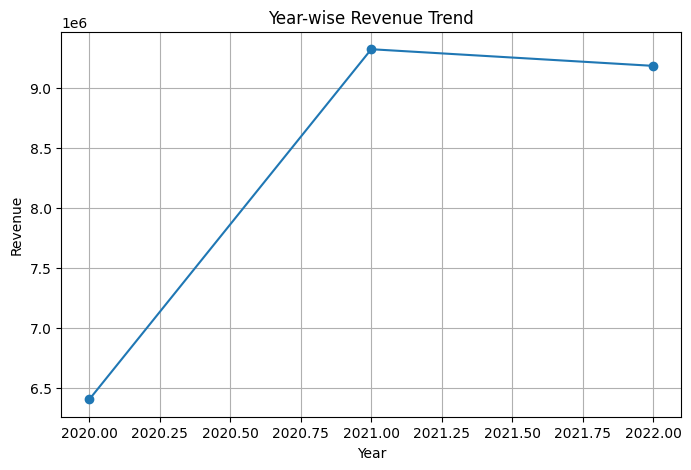

In [36]:
yearly_sales = final_df.groupby('Year')['Revenue'].sum()
yearly_sales

plt.figure(figsize=(8,5))
yearly_sales.plot(kind='line', marker='o')
plt.title('Year-wise Revenue Trend')
plt.xlabel('Year')
plt.ylabel('Revenue')
plt.grid(True)
plt.show()

In [37]:
monthly_sales = final_df.groupby(['Year','Month'])['Revenue'].sum()
monthly_sales

Year  Month
2020  1        5.853126e+05
      2        5.322262e+05
      3        6.434361e+05
      4        6.533640e+05
      5        6.593259e+05
      6        6.699887e+05
      7        4.861150e+05
      8        5.364528e+05
      9        3.440629e+05
      10       4.042766e+05
      11       3.266112e+05
      12       5.637615e+05
2021  1        4.324257e+05
      2        4.741628e+05
      3        4.719619e+05
      4        4.949574e+05
      5        5.455347e+05
      6        5.338250e+05
      7        8.153565e+05
      8        8.041934e+05
      9        9.527435e+05
      10       1.029821e+06
      11       1.133913e+06
      12       1.635309e+06
2022  1        1.274379e+06
      2        1.339241e+06
      3        1.448596e+06
      4        1.527814e+06
      5        1.768433e+06
      6        1.826987e+06
Name: Revenue, dtype: float64

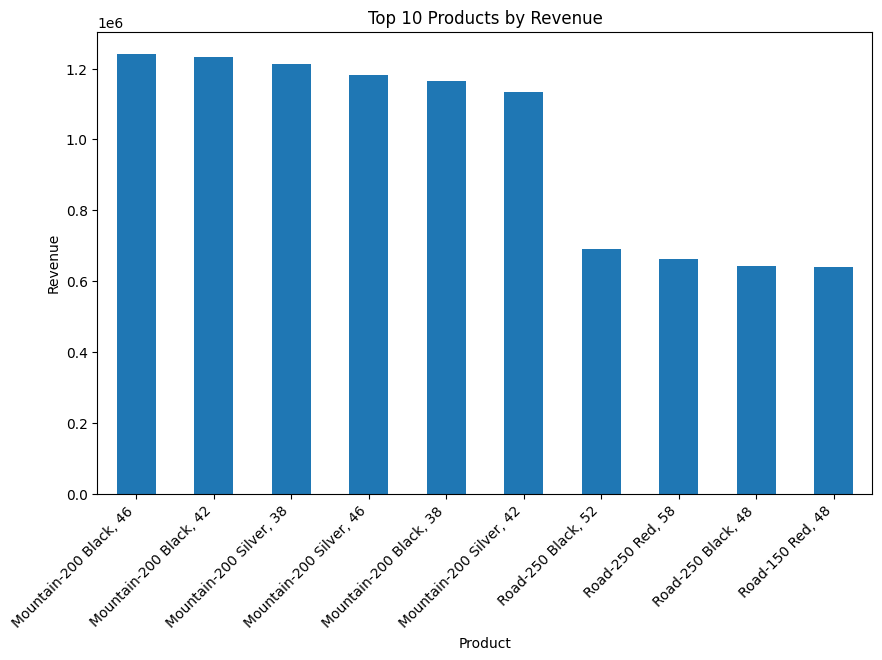

In [38]:
top_products = (
    final_df.groupby('ProductName')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
top_products

plt.figure(figsize=(10,6))
top_products.plot(kind='bar')
plt.title('Top 10 Products by Revenue')
plt.xlabel('Product')
plt.ylabel('Revenue')
plt.xticks(rotation=45, ha='right')
plt.show()

In [39]:
profit_by_category = (
    final_df.groupby('CategoryName')['Profit']
    .sum()
    .sort_values(ascending=False)
)
profit_by_category

CategoryName
Bikes          9.726168e+06
Accessories    5.697601e+05
Clothing       1.617871e+05
Name: Profit, dtype: float64

In [40]:
region_sales = (
    final_df.groupby('Region')['Revenue']
    .sum()
    .sort_values(ascending=False)
)
region_sales

Region
Australia         7.416456e+06
Southwest         4.822795e+06
Northwest         3.095074e+06
United Kingdom    2.902562e+06
Germany           2.524680e+06
France            2.362643e+06
Canada            1.769246e+06
Southeast         1.158562e+04
Northeast         6.401568e+03
Central           3.143060e+03
Name: Revenue, dtype: float64

In [41]:
top_customers = (
    final_df.groupby('CustomerKey')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
top_customers

CustomerKey
11433    12407.9545
11439    12015.4029
11241    11330.4494
11417    11085.7504
11420    11022.4002
11242    10852.0340
13263    10436.5079
12655    10394.9836
11425    10391.4304
12631    10331.7349
Name: Revenue, dtype: float64

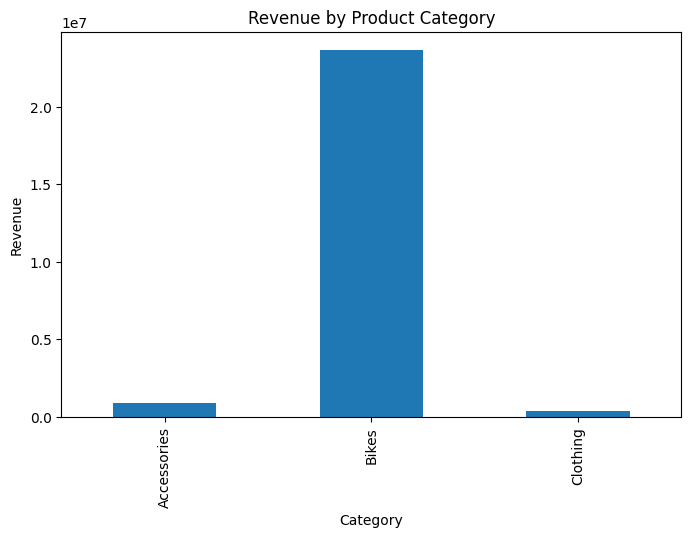

In [42]:
category_sales = final_df.groupby('CategoryName')['Revenue'].sum()

plt.figure(figsize=(8,5))
category_sales.plot(kind='bar')
plt.title('Revenue by Product Category')
plt.xlabel('Category')
plt.ylabel('Revenue')
plt.show()

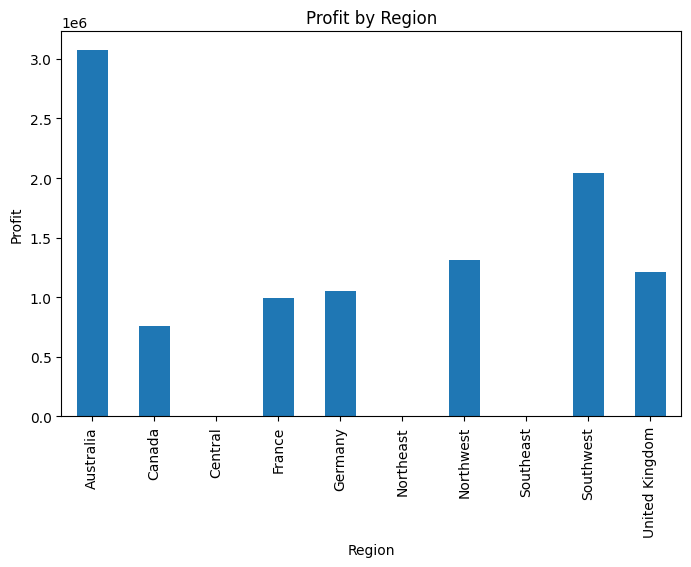

In [43]:
region_profit = final_df.groupby('Region')['Profit'].sum()

plt.figure(figsize=(8,5))
region_profit.plot(kind='bar')
plt.title('Profit by Region')
plt.xlabel('Region')
plt.ylabel('Profit')
plt.show()

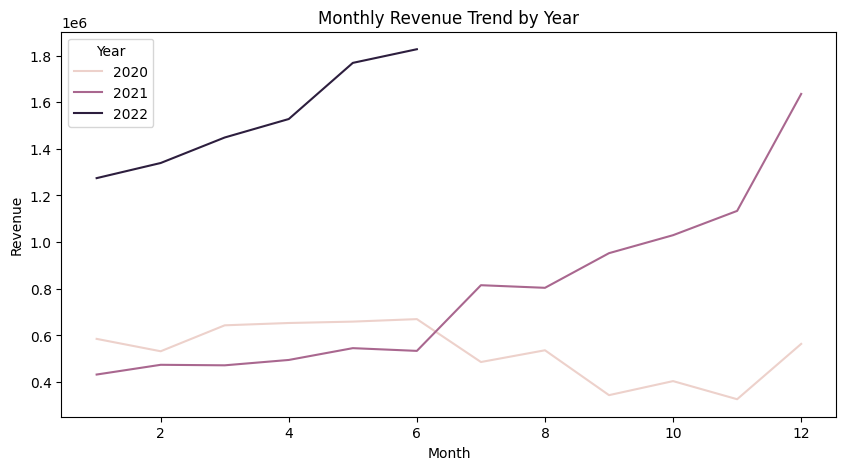

In [44]:
monthly_sales = final_df.groupby(['Year','Month'])['Revenue'].sum().reset_index()

plt.figure(figsize=(10,5))
seb.lineplot(data=monthly_sales, x='Month', y='Revenue', hue='Year')
plt.title('Monthly Revenue Trend by Year')
plt.show()

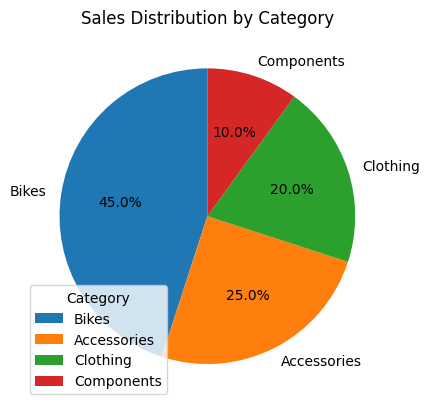

In [45]:
import matplotlib.pyplot as plt

# Example data
labels = ['Bikes', 'Accessories', 'Clothing', 'Components']
sizes = [45, 25, 20, 10]

plt.figure()
plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Sales Distribution by Category')
plt.legend(title = "Category", loc = "lower left")
plt.show()